In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [17]:
def time_axis(fs, duration):
    return np.arange(0, duration, 1/fs)
def generate_sine(f, t, a = 1, p = 0):
    return a*np.sin(2*np.pi*f*t + p)
def spectrum(x):
    X = np.fft.fft(x)
    N = len(X)//2 +1
    X = X[:N]

    mag = np.abs(X) *2/N
    mag[0] = mag[0]/2
    mag[-1]= mag[-1]/2
    freq= np.arange(len(mag)) * fs/N
    return freq, mag


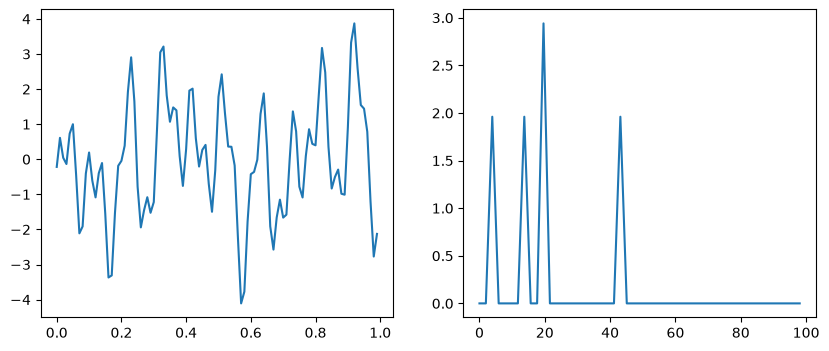

In [18]:
fs = 100
duration = 1
t = time_axis(fs, duration)
x = generate_sine(2, t, 1, np.pi) + generate_sine(7, t, 1, -np.pi/2) + generate_sine(10, t, 1.5, 0) + generate_sine(22, t, 1, 2*np.pi/7)
freq, mag = spectrum(x)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, x)
plt.subplot(1, 2, 2)
plt.plot(freq, mag)

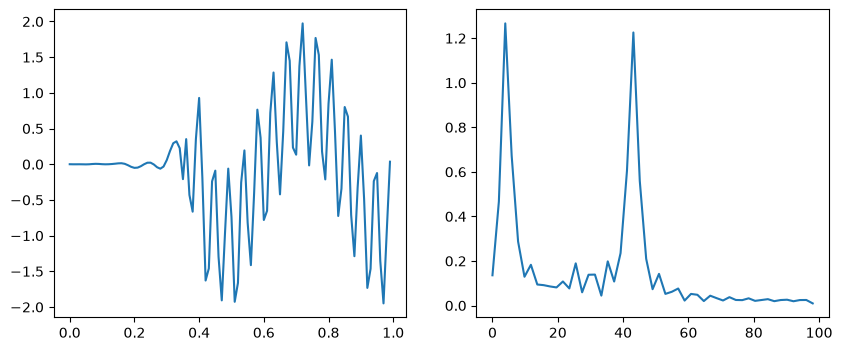

In [34]:
#using firwin delete 7 & 10 Hz
b = signal.firwin(numtaps = 71, cutoff = [5, 12], fs = fs, pass_zero = "bandstop")
a = [1.0]
y = signal.lfilter(b, a, x)
freq, mag = spectrum(y)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, y)
plt.subplot(1, 2, 2)
plt.plot(freq, mag)

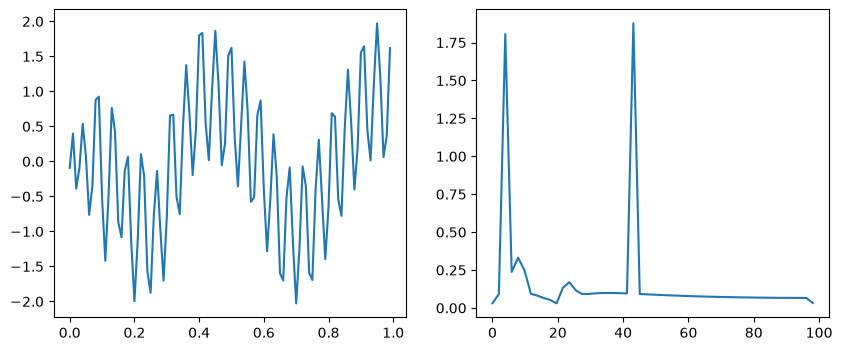

In [36]:
#using IIR design butterworth delete 7 & 10 Hz
b, a = signal.butter(N = 6, Wn = [5, 12], btype="bandstop", fs = fs)
y = signal.lfilter(b, a, x)
freq, mag = spectrum(y)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, y)
plt.subplot(1, 2, 2)
plt.plot(freq, mag)

using feedback help remove the unwanted frequency by using less b than the feedforward